In [1]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import pandas as pd
import numpy as np
import copy
import seaborn as sns
from scipy.stats import mannwhitneyu as mwu
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import wilcoxon
from scipy.optimize import curve_fit
from scipy.stats import fisher_exact
import os
from scipy.stats import combine_pvalues
from scipy.stats import spearmanr,pearsonr
from collections import Counter
import sys
from math import floor
from scipy.stats import binomtest

sns.set_style("white")
sns.set(font_scale = 1.5)
sns.set_style("white")

hfont = {'fontname':'Arial'}
plt.rcParams["font.family"] = "Arial"

#Code borrowed heavily from here: https://stackoverflow.com/questions/62375034/find-non-overlapping-area-between-two-kde-plots
plt.rcParams.update(
    {"text.usetex": False}
)

palette = {"Human accelerated":"#E31A1C", "Chimp accelerated":"#0058FF", "Not significant":"grey", "Human":"#E31A1C", "Chimp":"#0058FF"}

In [18]:
hum_ret_ls = [0.61, 0.59, 0.62, 0.81, 0.64, 0.59, 0.72, 0.85, 0.66, 0.44, 0.49, 0.50]
lca_ret_ls = [1.29, 1.23, 1.51, 1.82, 1.74, 1.40, 0.93, 1.19, 1.35, 1.61, 0.83, 0.64]
print(ttest_rel(hum_ret_ls, lca_ret_ls))

TtestResult(statistic=np.float64(-6.6577434748509345), pvalue=np.float64(3.5736460201253134e-05), df=np.int64(11))


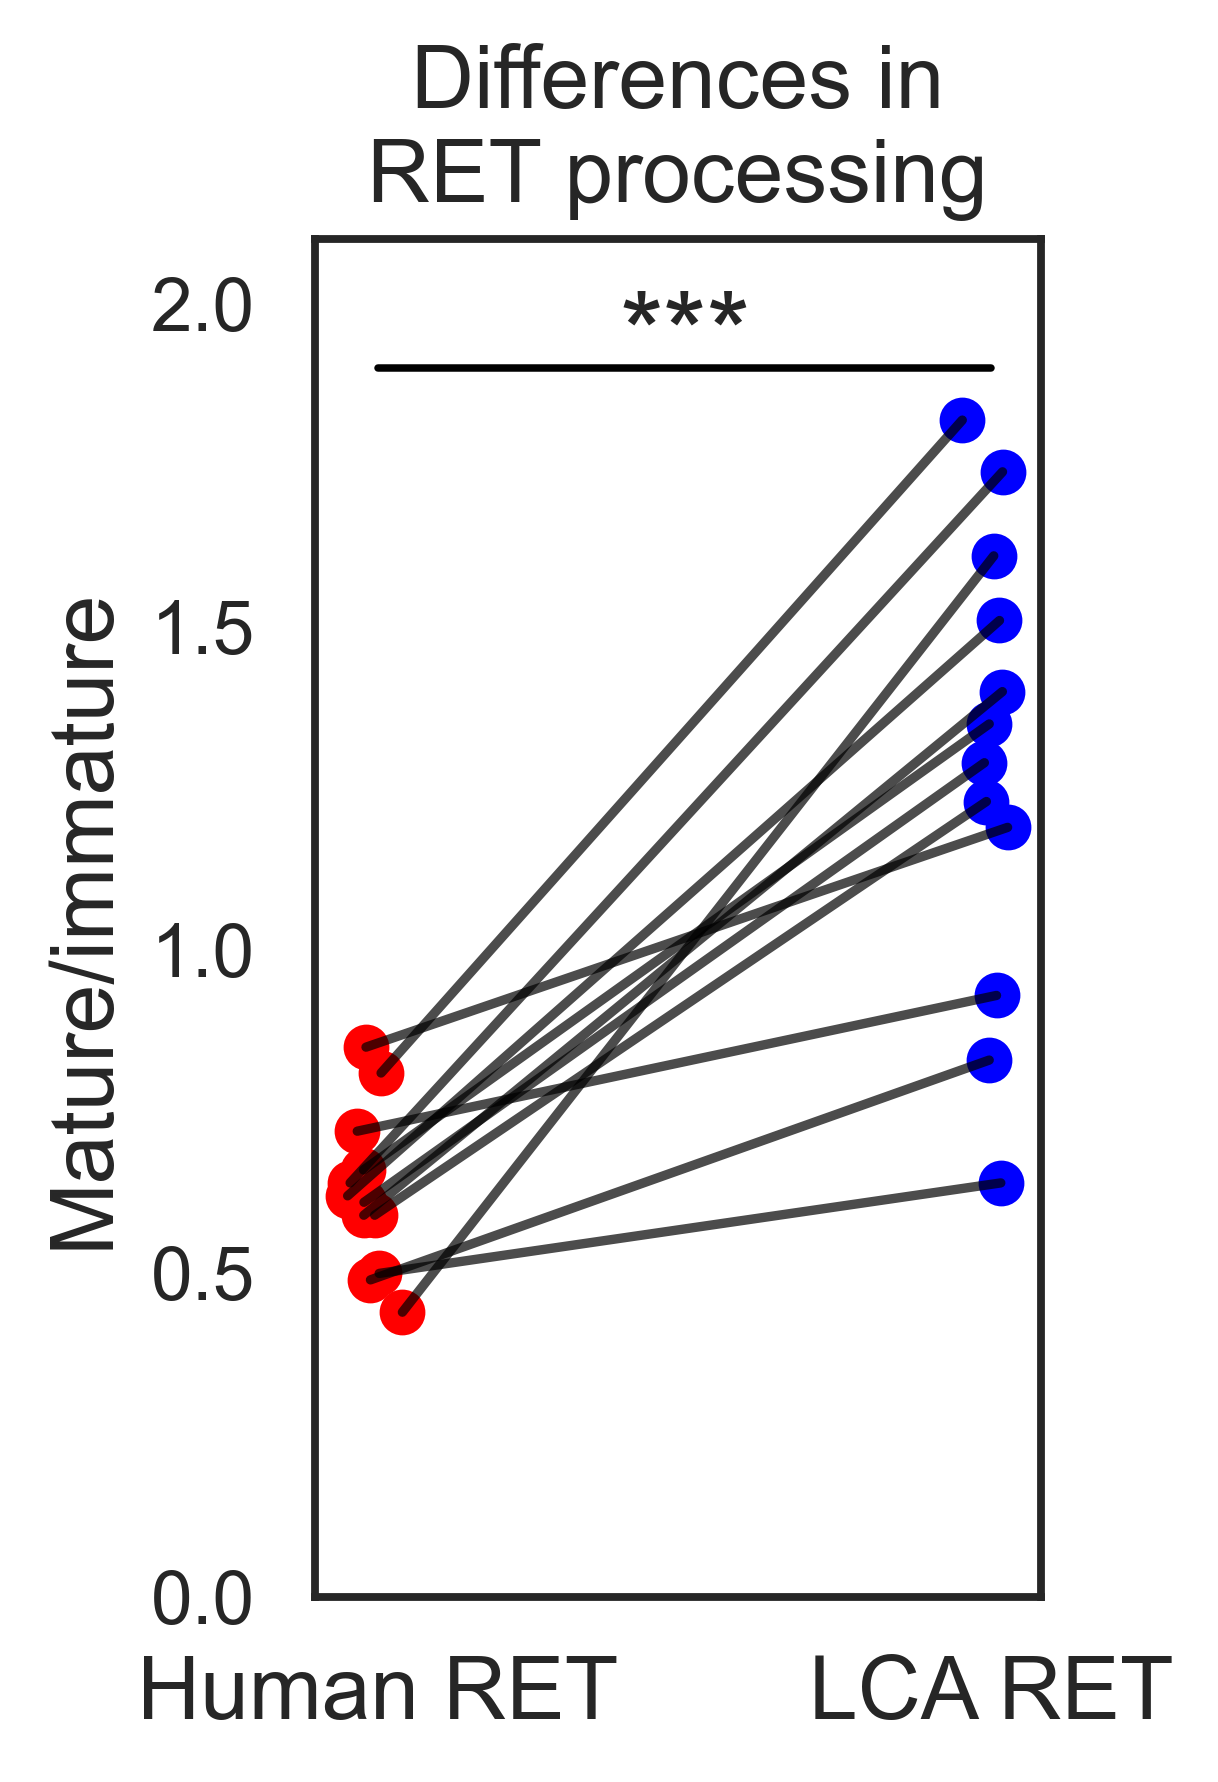

In [20]:
import matplotlib.pyplot as plt
import numpy as np

jitter = 0.05

plt.figure(figsize=(3,4.3), dpi = 450)

# --- Group 1 ---
for i in range(len(hum_ret_ls)):
    x_pre = 0 + np.random.uniform(-jitter, jitter)
    x_post = 1 + np.random.uniform(-jitter, jitter)
    
    plt.plot([x_pre, x_post],
             [hum_ret_ls[i], lca_ret_ls[i]],
             color='black', alpha=0.7)
    
    plt.scatter(x_pre, hum_ret_ls[i],
                color='red', s=40)

    # post = blue
    plt.scatter(x_post, lca_ret_ls[i],
                color='blue', s=40)



plt.xticks([0, 1],
           ['Human RET', 'LCA RET'], size = 12)

plt.ylabel('Mature/immature', size = 14)
plt.title('Differences in\nRET processing', size = 14)
plt.yticks(size = 12)
plt.xticks(size = 14)

#plt.axvline(1.5, linestyle='--', color='gray', alpha=1)  # separates groups

x1, x2 = 0, 1                 # bar positions
y, h = 1.9, 0             # height of line + vertical offset
plt.plot([x1, x1, x2, x2],
         [y, y + h, y + h, y],
         lw=1.2, c='black')

plt.text((x1 + x2) * 0.5, y - 0.04,
         "***",
         ha='center', va='bottom', fontsize=18)


plt.ylim(0, 2.1)
plt.tight_layout()
plt.show()

In [13]:
hum_ret = [4.31, 4.13, 0.81, 1.89, 3.34, 5.04, 1.34, 0.88, 0.74, 1.07, 0.72, 1.01]
lca_ret = [2.60, 3.93, 4.22, 3.15, 4.21, 6.71, 0.60, 0.22, 0.44, 0.36, 0.22, 0.24]
print(ttest_rel(hum_ret, lca_ret))

TtestResult(statistic=np.float64(-0.3312303591332668), pvalue=np.float64(0.7466947795419675), df=np.int64(11))


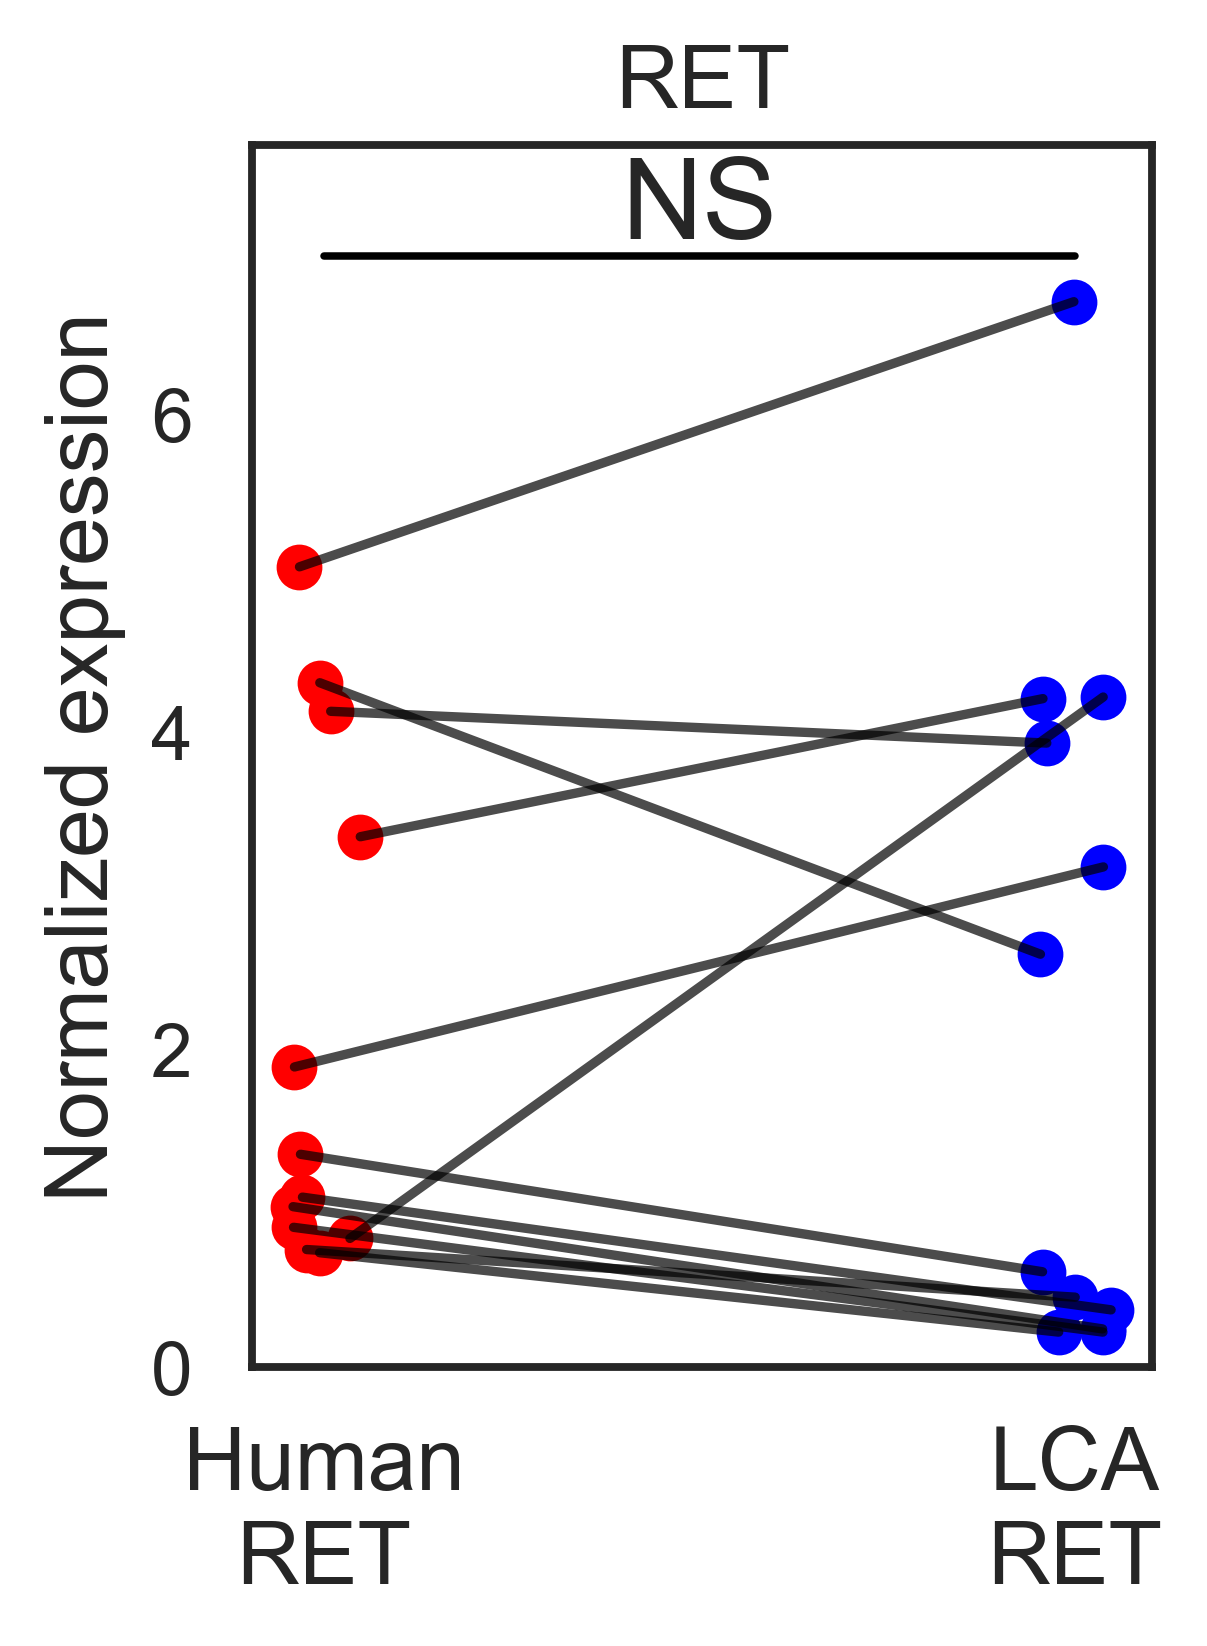

In [20]:

import matplotlib.pyplot as plt
import numpy as np

jitter = 0.05

plt.figure(figsize=(3,4), dpi = 450)

# --- Group 1 ---
for i in range(len(hum_ret)):
    x_pre = 0 + np.random.uniform(-jitter, jitter)
    x_post = 1 + np.random.uniform(-jitter, jitter)
    
    plt.plot([x_pre, x_post],
             [hum_ret[i], lca_ret[i]],
             color='black', alpha=0.7)
    
    plt.scatter(x_pre, hum_ret[i],
                color='red', s=40)

    # post = blue
    plt.scatter(x_post, lca_ret[i],
                color='blue', s=40)



plt.xticks([0, 1],
           ['Human\nRET', 'LCA\nRET'], size = 12)

plt.ylabel('Normalized expression', size = 14)
plt.title('RET', size = 14)
plt.yticks(size = 12)
plt.xticks(size = 14)

#plt.axvline(1.5, linestyle='--', color='gray', alpha=1)  # separates groups

x1, x2 = 0, 1                 # bar positions
y, h = 7, 0             # height of line + vertical offset
plt.plot([x1, x1, x2, x2],
         [y, y + h, y + h, y],
         lw=1.2, c='black')

plt.text((x1 + x2) * 0.5, y - 0.03,
         "NS",
         ha='center', va='bottom', fontsize=18)


plt.ylim(0, 7.7)
plt.tight_layout()
plt.show()



In [3]:
hum_esr1 = [0.258, 1.022, 0.777, 0.707, 1.160, 0.899, 0.624]
lca_esr1 = [0.680, 1.114, 0.940, 2.950, 1.762, 2.458, 1.835]

mut_hum_esr1 = [0.268, 0.432, 0.873]
mut_lca_esr1 = [0.154, 0.261, 0.288]


from scipy.stats import ttest_rel, ttest_ind
ttest_rel(hum_esr1, lca_esr1)


TtestResult(statistic=np.float64(-2.96961318965334), pvalue=np.float64(0.0249700249500775), df=np.int64(6))

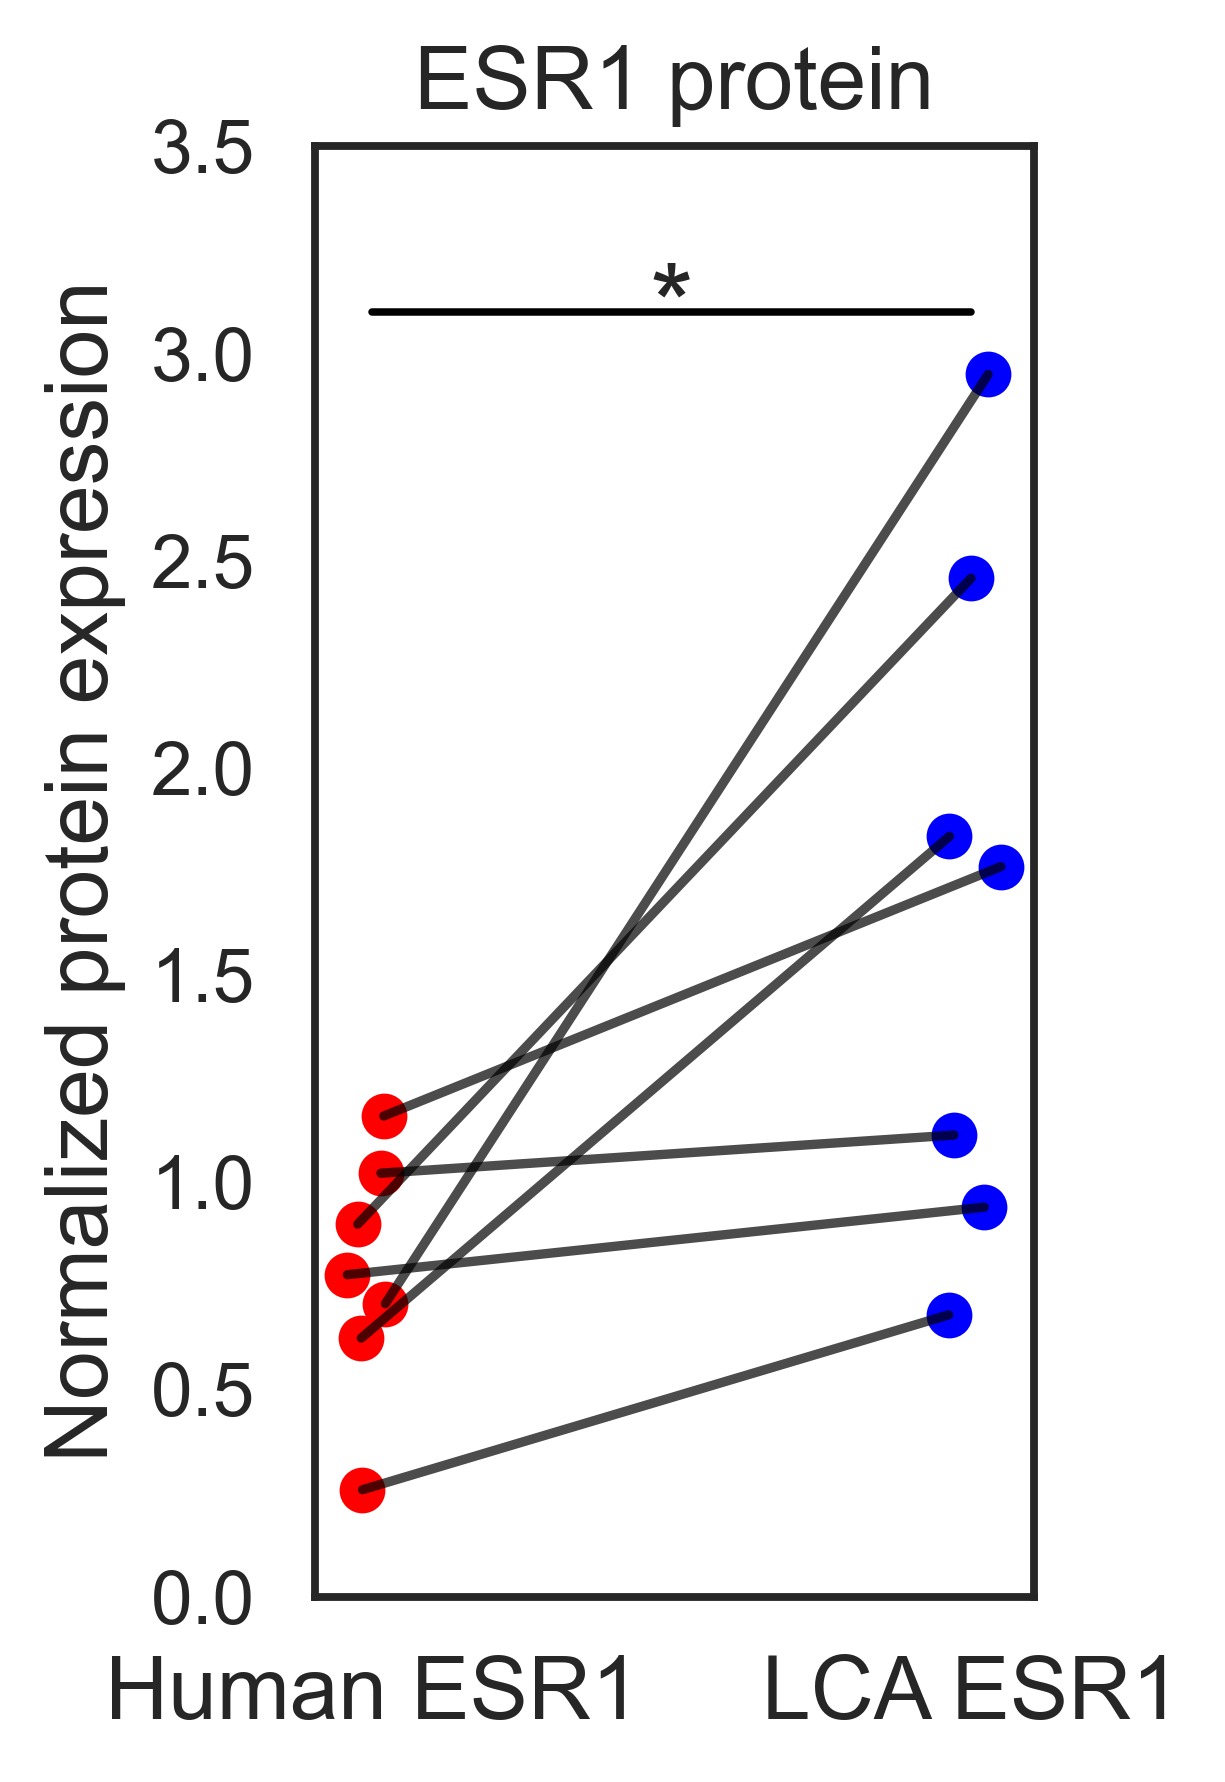

In [8]:

import matplotlib.pyplot as plt
import numpy as np

jitter = 0.05

plt.figure(figsize=(3,4.3), dpi = 450)

# --- Group 1 ---
for i in range(len(hum_esr1)):
    x_pre = 0 + np.random.uniform(-jitter, jitter)
    x_post = 1 + np.random.uniform(-jitter, jitter)
    
    plt.plot([x_pre, x_post],
             [hum_esr1[i], lca_esr1[i]],
             color='black', alpha=0.7)
    
    plt.scatter(x_pre, hum_esr1[i],
                color='red', s=40)

    # post = blue
    plt.scatter(x_post, lca_esr1[i],
                color='blue', s=40)



plt.xticks([0, 1],
           ['Human ESR1', 'LCA ESR1'], size = 10)

plt.ylabel('Normalized protein expression', size = 14)
plt.title('ESR1 protein', size = 14)
plt.yticks(size = 12)
plt.xticks(size = 14)

#plt.axvline(1.5, linestyle='--', color='gray', alpha=1)  # separates groups

x1, x2 = 0, 1                 # bar positions
y, h = 3.1, 0             # height of line + vertical offset
plt.plot([x1, x1, x2, x2],
         [y, y + h, y + h, y],
         lw=1.2, c='black')

plt.text((x1 + x2) * 0.5, y - 0.13,
         "*",
         ha='center', va='bottom', fontsize=18)


plt.ylim(0, 3.5)
plt.tight_layout()
plt.show()



In [4]:
fc_norm = np.log2(np.array(hum_esr1)/np.array(lca_esr1))
fc_mut = np.log2(np.array(mut_hum_esr1)/np.array(mut_lca_esr1))

ttest_ind(fc_norm, fc_mut)
fc_norm

array([-1.39816368, -0.12435404, -0.27474616, -2.06093283, -0.60308912,
       -1.45109189, -1.55616213])

In [28]:
np.mean(fc_mut)

np.float64(1.042065665847861)

In [20]:
import matplotlib

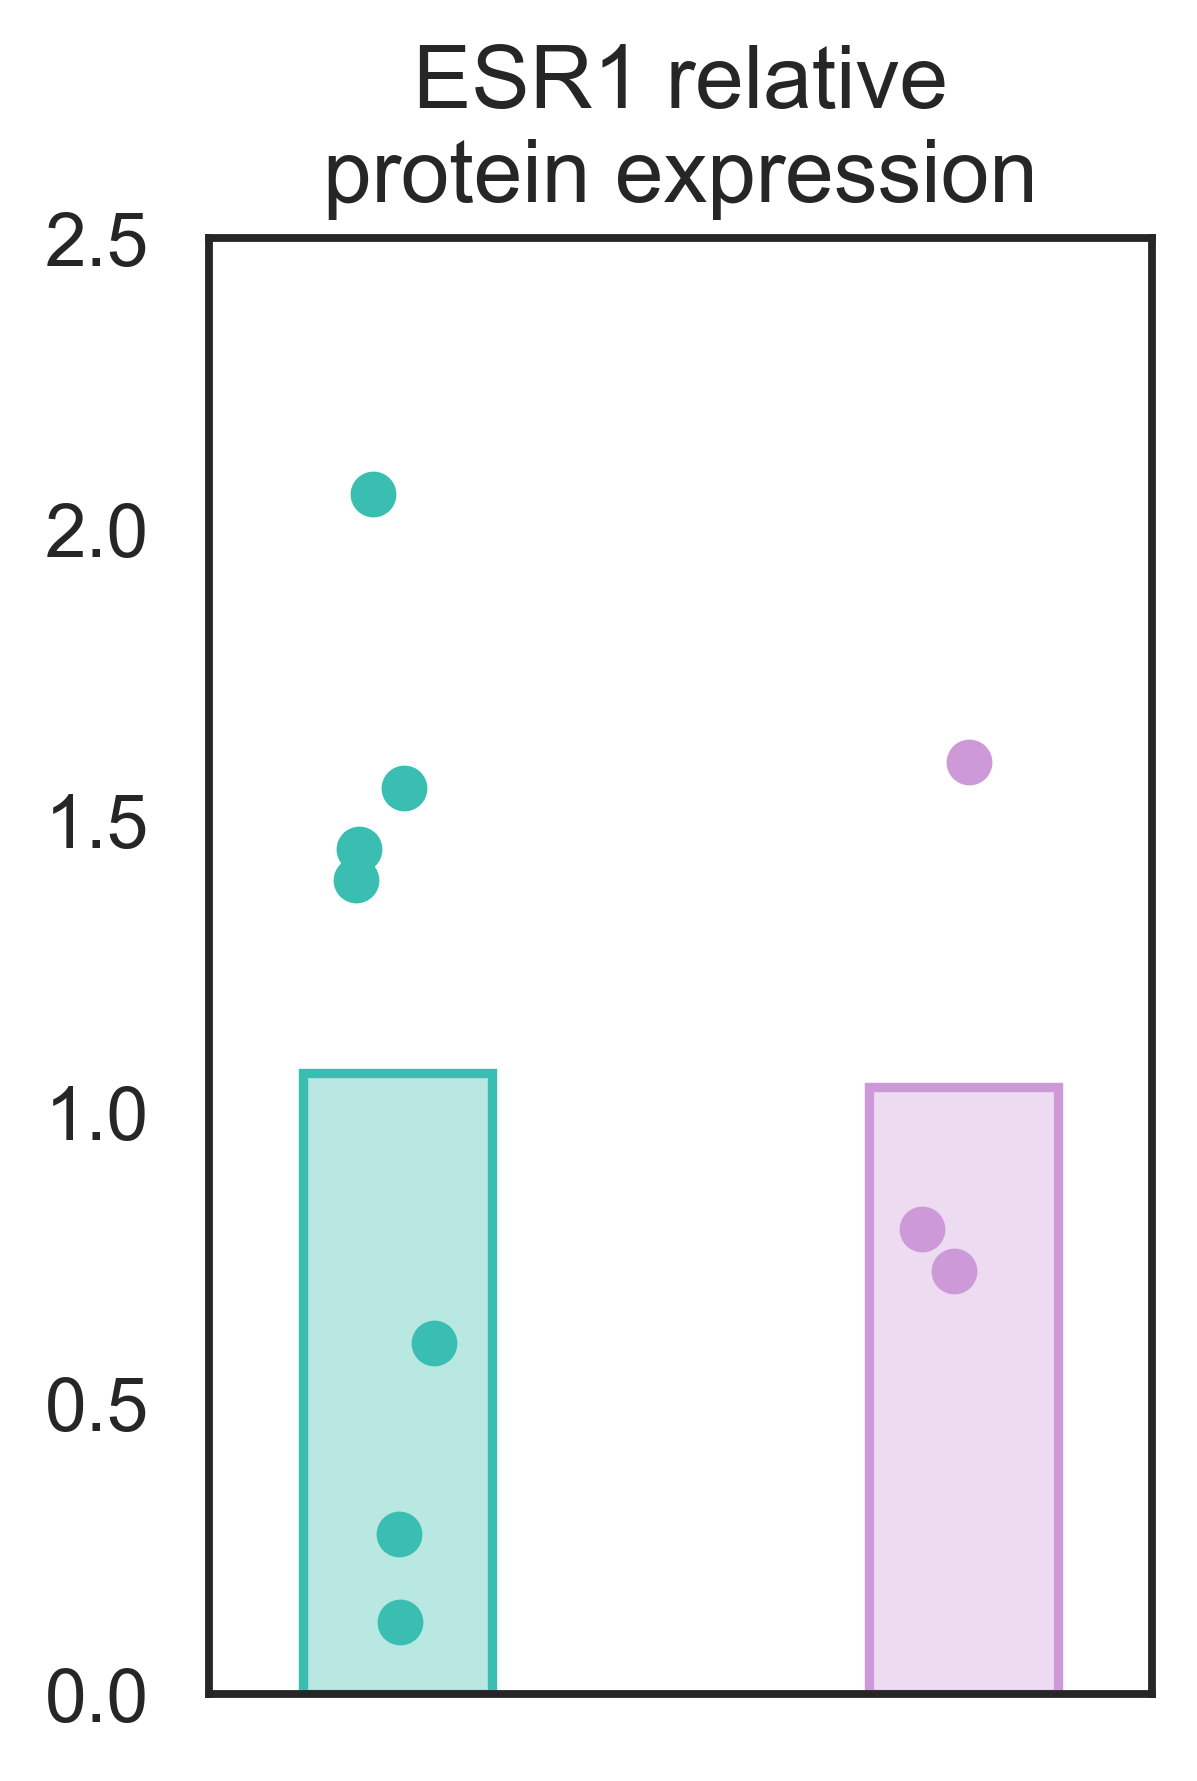

In [10]:
import matplotlib.pyplot as plt
import numpy as np
jitter = 0.05
fig, ax = plt.subplots(figsize=(3,4.3), dpi=450)

# --- Compute means ---
mean_norm = np.mean(-np.array(fc_norm))
mean_mut  = np.mean([fc_mut[i] for i in range(min(3, len(fc_mut)))])
bar_half_width = 0.1

# --- Mean bars rooted at y=0 (filled with alpha=0.35, outline with alpha=1) ---
# ESR1 mean bar (teal)
rect_norm = plt.Rectangle((0.2 - bar_half_width, 0),
                           2 * bar_half_width, mean_norm,
                           facecolor='#39BEB1', alpha=0.35,
                           edgecolor='none', linewidth=1.5, zorder=1)
ax.add_patch(rect_norm)
rect_norm_edge = plt.Rectangle((0.2 - bar_half_width, 0),
                                2 * bar_half_width, mean_norm,
                                facecolor='none', alpha=1.0,
                                edgecolor='#39BEB1', linewidth=1.5, zorder=1)
ax.add_patch(rect_norm_edge)

# ESR1 2AA swap mean bar (purple)
rect_mut = plt.Rectangle((0.8 - bar_half_width, 0),
                          2 * bar_half_width, mean_mut,
                          facecolor='#CD99D8', alpha=0.35,
                          edgecolor='none', linewidth=1.5, zorder=1)
ax.add_patch(rect_mut)
rect_mut_edge = plt.Rectangle((0.8 - bar_half_width, 0),
                               2 * bar_half_width, mean_mut,
                               facecolor='none', alpha=1.0,
                               edgecolor='#CD99D8', linewidth=1.5, zorder=1)
ax.add_patch(rect_mut_edge)

# --- Group 1 ---
for i in range(len(fc_norm)):
    x_pre = 0.2 + np.random.uniform(-jitter, jitter)
    x_post = 0.8 + np.random.uniform(-jitter, jitter)
    ax.scatter(x_pre, -fc_norm[i], color='#39BEB1', s=40, zorder=3)
    if i < 3:
        ax.scatter(x_post, fc_mut[i], color='#CD99D8', s=40, zorder=3)

#ax.set_xticks([0.15, 0.85])
ax.set_xticklabels([], size=10)
ax.set_ylabel('', size=14)
#ax.secondary_yaxis('right').set_ylabel('log$_{2}$(LCA 2AA swap/human 2AA swap)', size=14, rotation=0)
#sec = ax.secondary_yaxis('right')
#sec.set_ylabel('log$_{2}$(LCA swap/human swap)', size=14, rotation=90, labelpad=20)
#sec.set_ticks([])

#sec = ax.secondary_yaxis('right')
#lbl = sec.set_ylabel('your label here', size=14, rotation=90)
#lbl.set_transform(lbl.get_transform() + #matplotlib.transforms.Affine2D().scale(-1, 1))
#sec.set_ticks([])

ax.set_title('ESR1 relative\nprotein expression', size=14)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=14)
ax.set_ylim(0, 2.5)
ax.set_xlim(0, 1)

# Draw x-axis spine on top to cover the bottom bar edges
ax.spines['bottom'].set_zorder(5)

plt.tight_layout()
plt.show()

In [3]:
fc_norm = np.log2(np.array(hum_esr1)/np.array(lca_esr1))
fc_mut = np.log2(np.array(mut_hum_esr1)/np.array(mut_lca_esr1))

ttest_ind(fc_norm, fc_mut)

TtestResult(statistic=np.float64(-4.502959774568026), pvalue=np.float64(0.001994274870384896), df=np.float64(8.0))

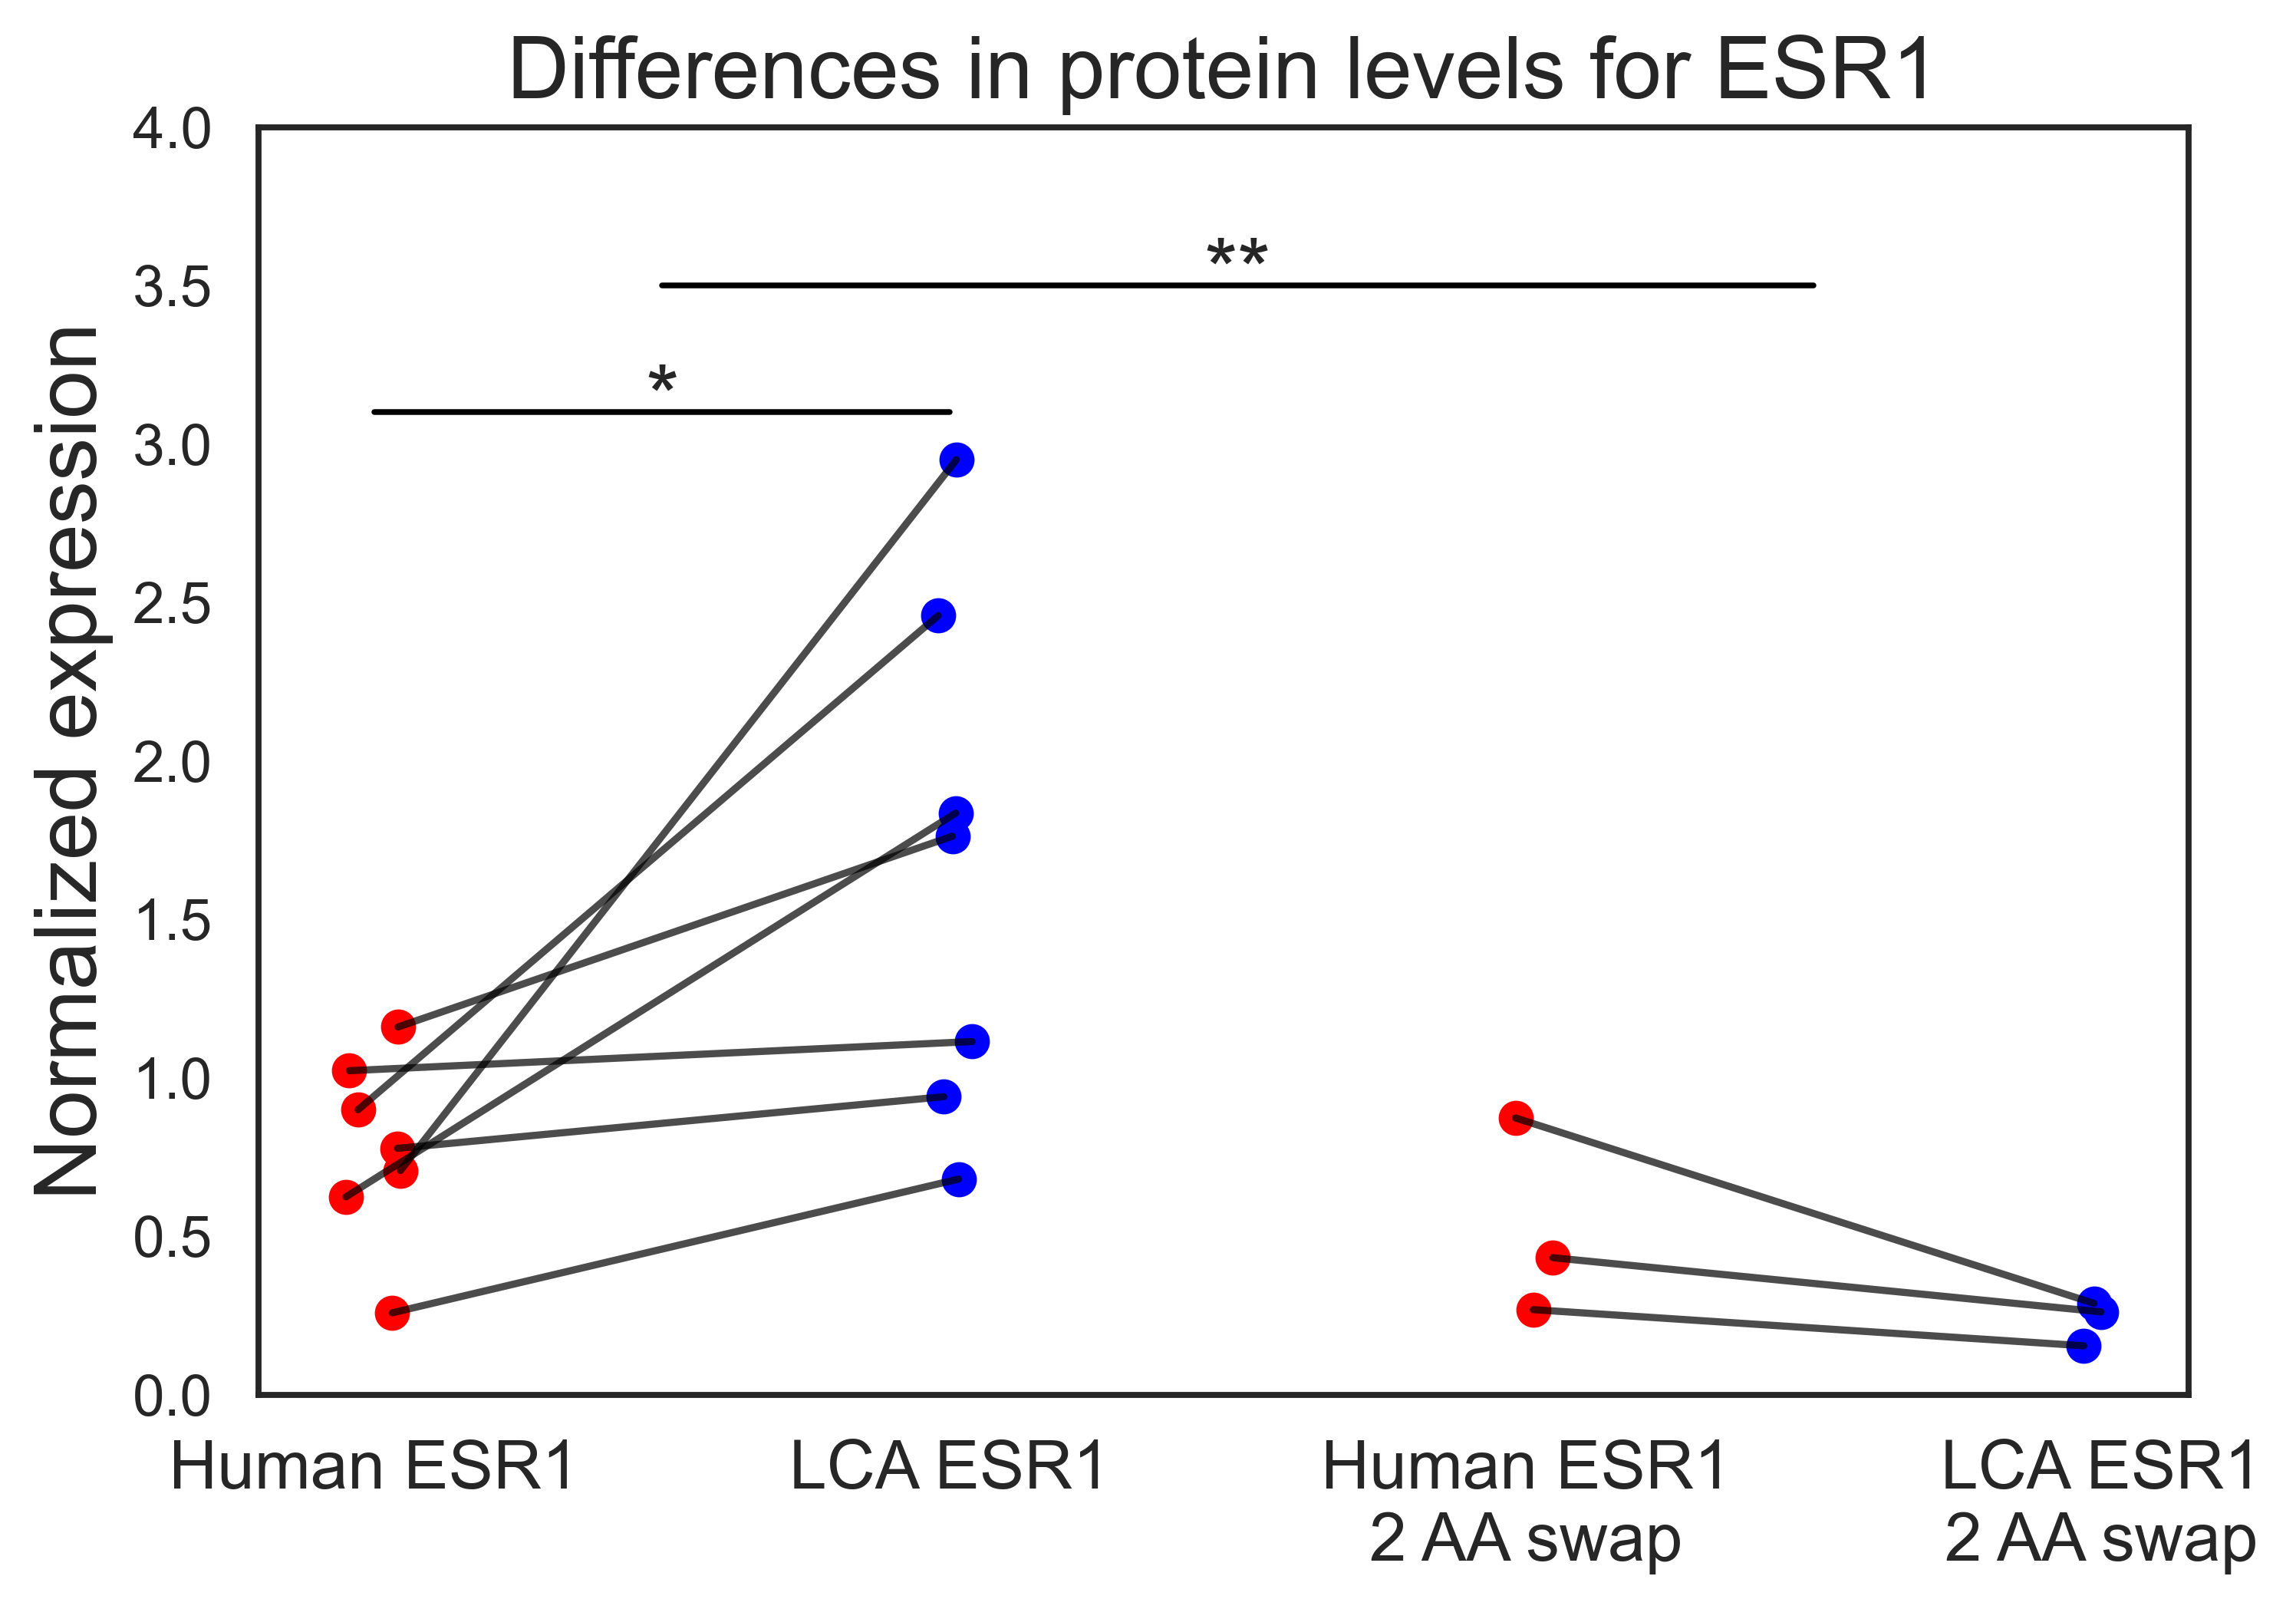

In [7]:
import matplotlib.pyplot as plt
import numpy as np

jitter = 0.05

plt.figure(figsize=(7,5), dpi = 450)

# --- Group 1 ---
for i in range(len(hum_esr1)):
    x_pre = 0 + np.random.uniform(-jitter, jitter)
    x_post = 1 + np.random.uniform(-jitter, jitter)
    
    plt.plot([x_pre, x_post],
             [hum_esr1[i], lca_esr1[i]],
             color='black', alpha=0.7)
    
    plt.scatter(x_pre, hum_esr1[i],
                color='red', s=40)

    # post = blue
    plt.scatter(x_post, lca_esr1[i],
                color='blue', s=40)

# --- Group 2 ---
for i in range(len(mut_hum_esr1)):
    x_pre = 2 + np.random.uniform(-jitter, jitter)
    x_post = 3 + np.random.uniform(-jitter, jitter)
    
    plt.plot([x_pre, x_post],
             [mut_hum_esr1[i], mut_lca_esr1[i]],
             color='black', alpha=0.7)
    
    plt.scatter(x_pre, mut_hum_esr1[i],
                color='red', s=40)

    # post = blue
    plt.scatter(x_post, mut_lca_esr1[i],
                color='blue', s=40)

plt.xticks([0, 1, 2, 3],
           ['Human ESR1', 'LCA ESR1', 'Human ESR1\n2 AA swap', 'LCA ESR1\n2 AA swap'], size = 12)

plt.ylabel('Normalized expression')
plt.title('Differences in protein levels for ESR1')
plt.yticks(size = 12)
plt.xticks(size = 14)

#plt.axvline(1.5, linestyle='--', color='gray', alpha=1)  # separates groups

x1, x2 = 0, 1                 # bar positions
y, h = 3.1, 0             # height of line + vertical offset
plt.plot([x1, x1, x2, x2],
         [y, y + h, y + h, y],
         lw=1.2, c='black')

plt.text((x1 + x2) * 0.5, y - 0.1,
         "*",
         ha='center', va='bottom', fontsize=18)

x1, x2 = 0.5, 2.5                 # bar positions
y, h = 3.5, 0             # height of line + vertical offset
plt.plot([x1, x1, x2, x2],
         [y, y + h, y + h, y],
         lw=1.2, c='black')

plt.text((x1 + x2) * 0.5, y - 0.1,
         "**",
         ha='center', va='bottom', fontsize=18)

plt.ylim(0, 4)
plt.tight_layout()
plt.show()

In [32]:
hum_eya1 = [0.577, 0.582, 0.107, 0.626, 0.818, 0.529, 0.389]
lca_eya1 = [0.097, 0.242, 0.102, 0.476, 0.558, 0.325, 0.246]
ttest_rel(hum_eya1, lca_eya1)

TtestResult(statistic=np.float64(3.90526820298363), pvalue=np.float64(0.007935582894230088), df=np.int64(6))

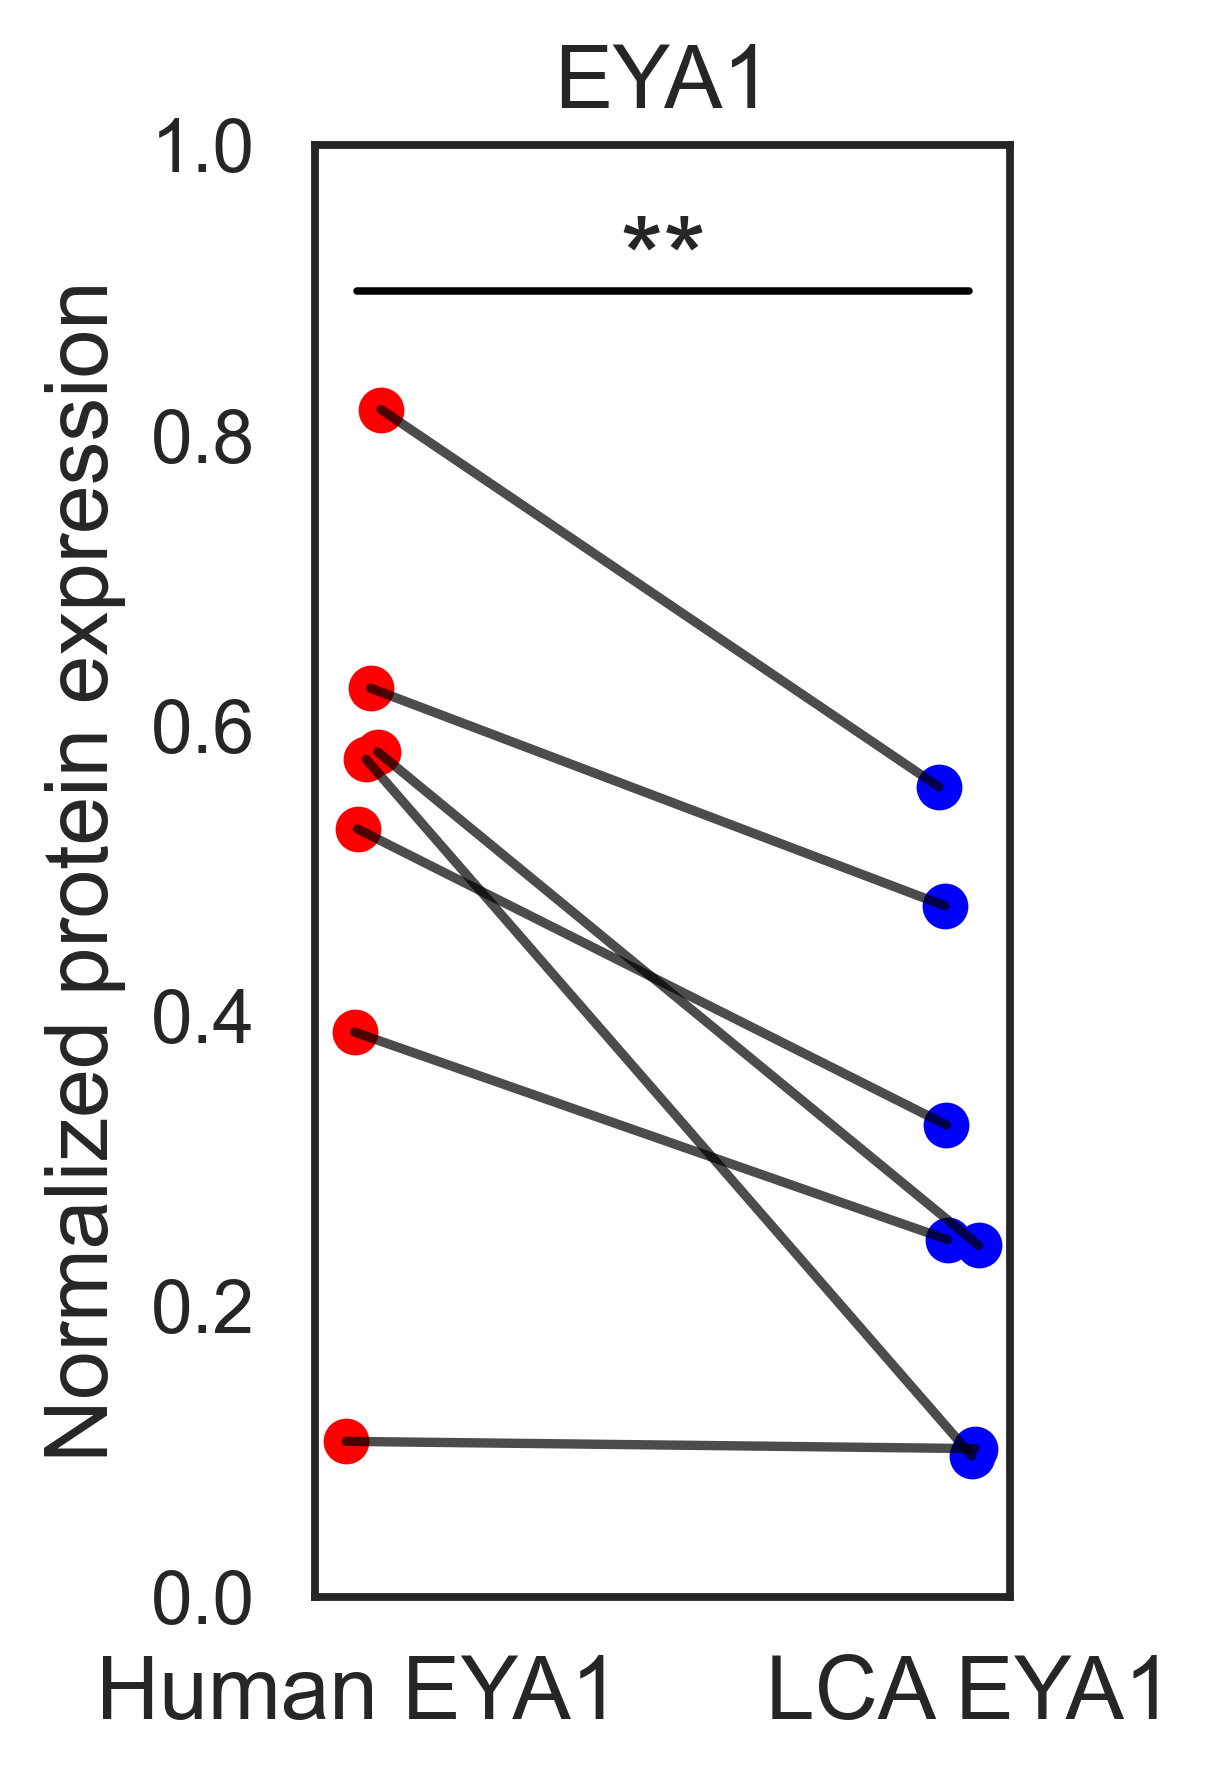

In [16]:
hum_eya1 = [0.577, 0.582, 0.107, 0.626, 0.818, 0.529, 0.389]
lca_eya1 = [0.097, 0.242, 0.102, 0.476, 0.558, 0.325, 0.246]

import matplotlib.pyplot as plt
import numpy as np

jitter = 0.05

plt.figure(figsize=(3,4.3), dpi = 450)

# --- Group 1 ---
for i in range(len(hum_eya1)):
    x_pre = 0 + np.random.uniform(-jitter, jitter)
    x_post = 1 + np.random.uniform(-jitter, jitter)
    
    plt.plot([x_pre, x_post],
             [hum_eya1[i], lca_eya1[i]],
             color='black', alpha=0.7)
    
    plt.scatter(x_pre, hum_eya1[i],
                color='red', s=40)

    # post = blue
    plt.scatter(x_post, lca_eya1[i],
                color='blue', s=40)



plt.xticks([0, 1],
           ['Human EYA1', 'LCA EYA1'], size = 10)

plt.ylabel('Normalized protein expression', size = 14)
plt.title('EYA1', size = 14)
plt.yticks(size = 12)
plt.xticks(size = 14)

#plt.axvline(1.5, linestyle='--', color='gray', alpha=1)  # separates groups

x1, x2 = 0, 1                 # bar positions
y, h = 0.9, 0             # height of line + vertical offset
plt.plot([x1, x1, x2, x2],
         [y, y + h, y + h, y],
         lw=1.2, c='black')

plt.text((x1 + x2) * 0.5, y - 0.02,
         "**",
         ha='center', va='bottom', fontsize=18)


plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [41]:
ttest_rel(hum_eya1, lca_eya1)

TtestResult(statistic=np.float64(3.90526820298363), pvalue=np.float64(0.007935582894230088), df=np.int64(6))

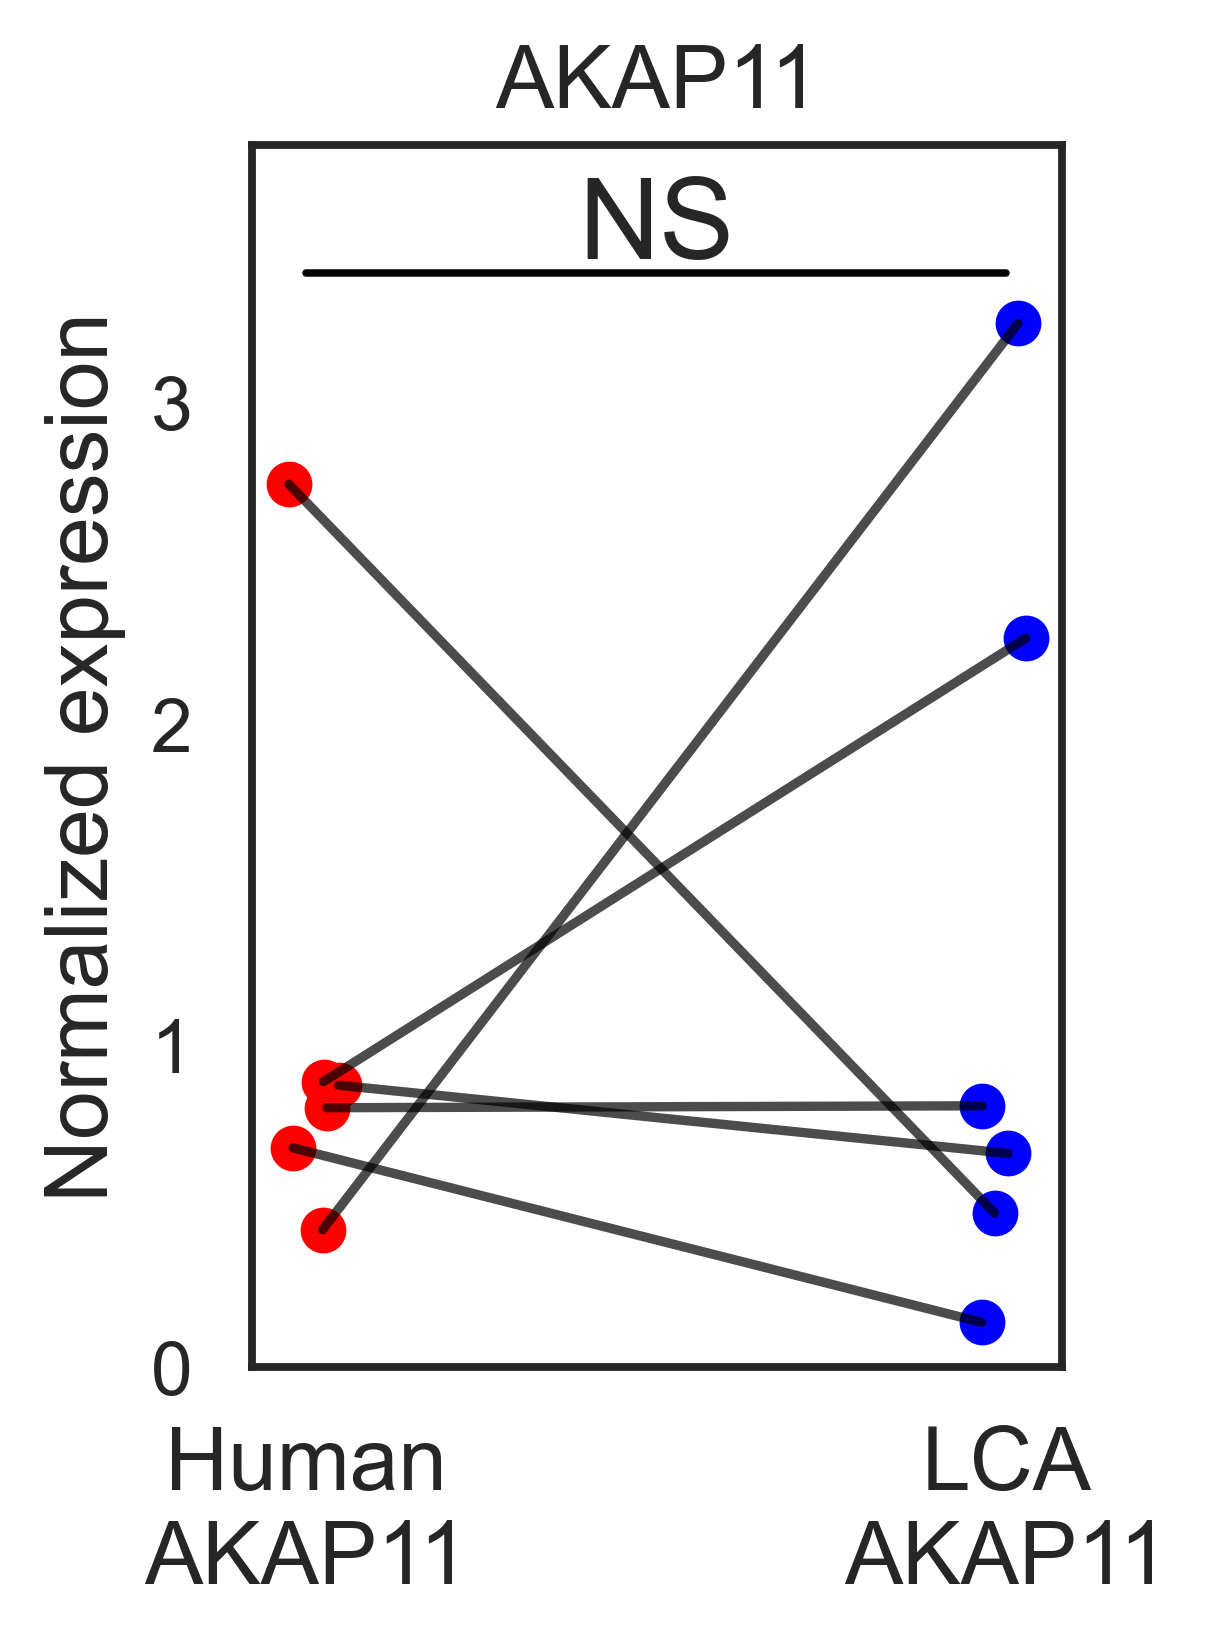

In [18]:
hum_akap11 = [0.681, 0.887, 2.744, 0.427, 0.876, 0.806]
lca_akap11 = [0.139, 2.265, 0.479, 3.244, 0.664, 0.812]

import matplotlib.pyplot as plt
import numpy as np
, 
jitter = 0.05

plt.figure(figsize=(3,4), dpi = 450)

# --- Group 1 ---
for i in range(len(hum_akap11)):
    x_pre = 0 + np.random.uniform(-jitter, jitter)
    x_post = 1 + np.random.uniform(-jitter, jitter)
    
    plt.plot([x_pre, x_post],
             [hum_akap11[i], lca_akap11[i]],
             color='black', alpha=0.7)
    
    plt.scatter(x_pre, hum_akap11[i],
                color='red', s=40)

    # post = blue
    plt.scatter(x_post, lca_akap11[i],
                color='blue', s=40)



plt.xticks([0, 1],
           ['Human\nAKAP11', 'LCA\nAKAP11'], size = 14)

plt.ylabel('Normalized expression', size = 14)
plt.title('AKAP11', size = 14)
plt.yticks(size = 12)

#plt.axvline(1.5, linestyle='--', color='gray', alpha=1)  # separates groups

x1, x2 = 0, 1                 # bar positions
y, h = 3.4, 0             # height of line + vertical offset
plt.plot([x1, x1, x2, x2],
         [y, y + h, y + h, y],
         lw=1.2, c='black')

plt.text((x1 + x2) * 0.5, y - 0.02,
         "NS",
         ha='center', va='bottom', fontsize=18)


plt.ylim(0, 3.8)
plt.tight_layout()
plt.show()

TtestResult(statistic=np.float64(-1.012663982825451), pvalue=np.float64(0.3449369300389026), df=np.int64(7))


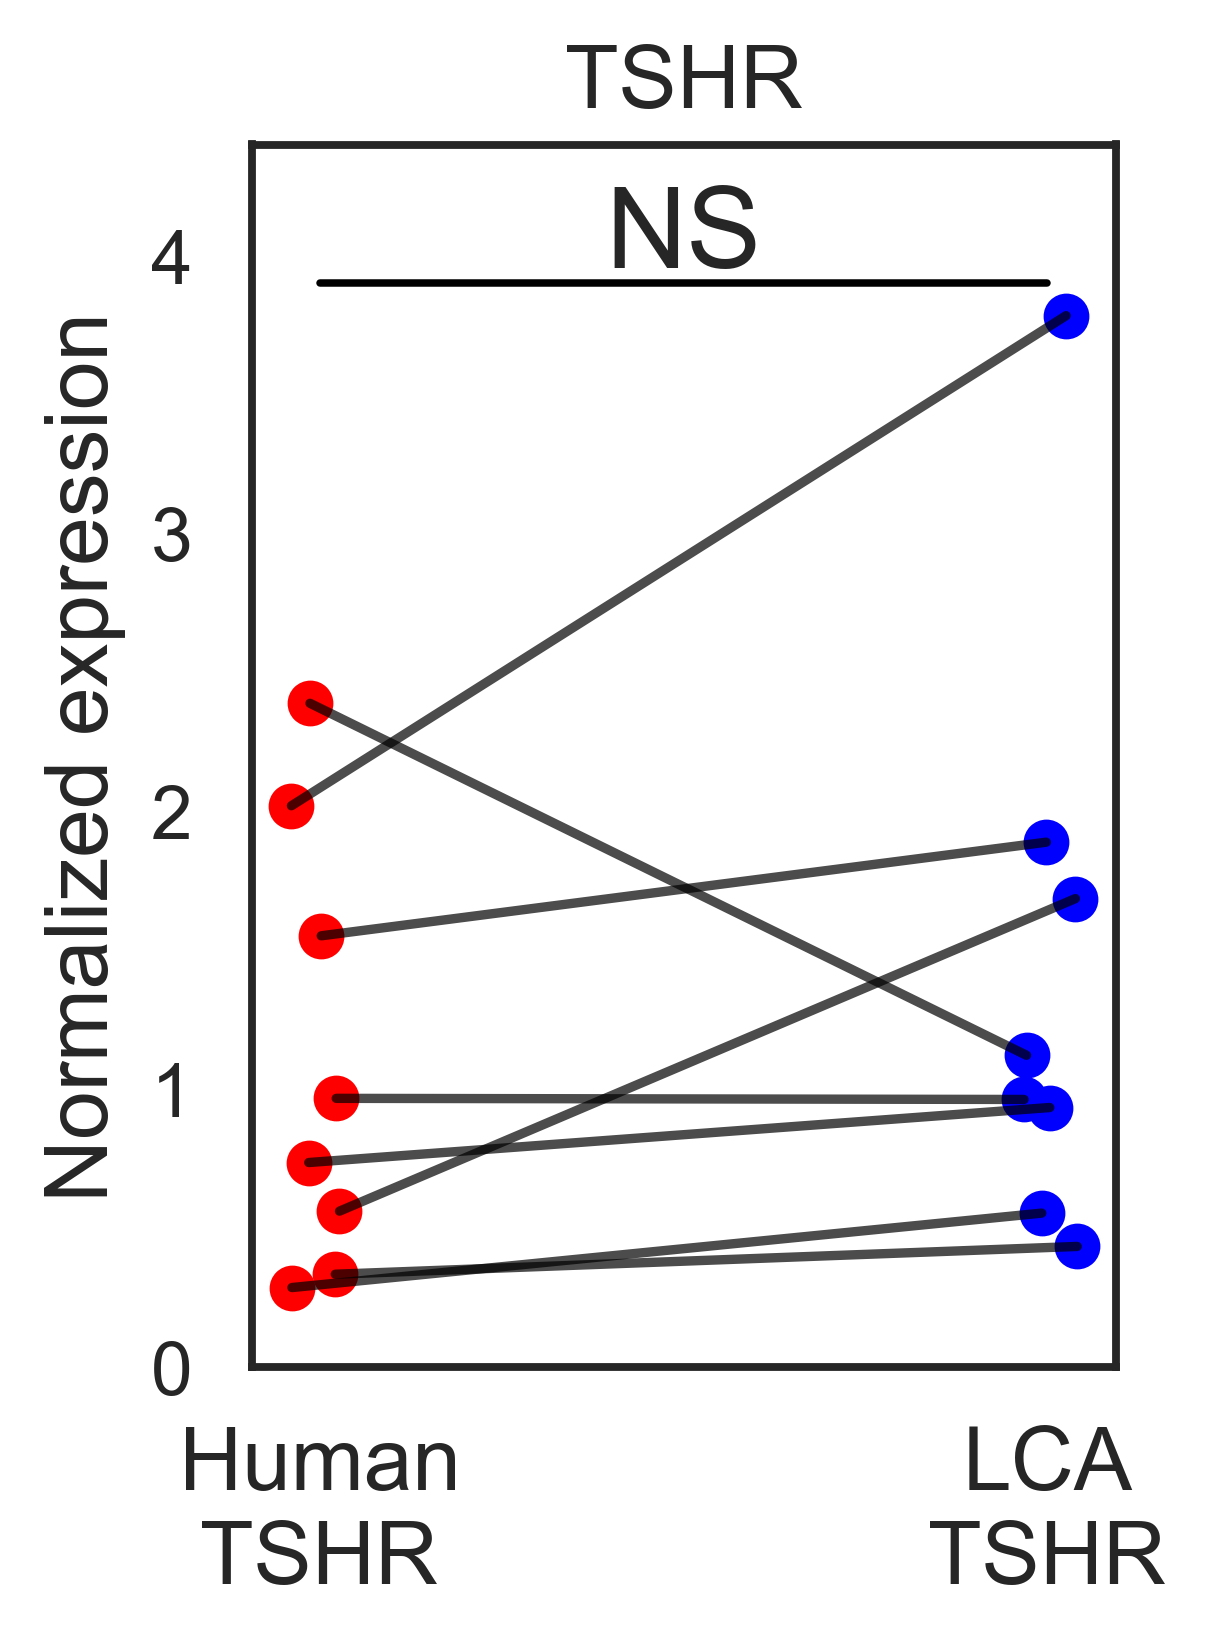

In [17]:
hum_tshr = [0.286, 0.561, 1.552, 2.020, 0.334, 2.389, 0.736, 0.967]
lca_tshr = [0.554, 1.686, 1.889, 3.784, 0.434, 1.122, 0.934, 0.963]

print(ttest_rel(hum_tshr, lca_tshr))

jitter = 0.05

plt.figure(figsize=(3,4), dpi = 450)

# --- Group 1 ---
for i in range(len(hum_tshr)):
    x_pre = 0 + np.random.uniform(-jitter, jitter)
    x_post = 1 + np.random.uniform(-jitter, jitter)
    
    plt.plot([x_pre, x_post],
             [hum_tshr[i], lca_tshr[i]],
             color='black', alpha=0.7)
    
    plt.scatter(x_pre, hum_tshr[i],
                color='red', s=40)

    # post = blue
    plt.scatter(x_post, lca_tshr[i],
                color='blue', s=40)



plt.xticks([0, 1],
           ['Human\nTSHR', 'LCA\nTSHR'], size = 14)

plt.ylabel('Normalized expression', size = 14)
plt.title('TSHR', size = 14)
plt.yticks(size = 12)

#plt.axvline(1.5, linestyle='--', color='gray', alpha=1)  # separates groups

x1, x2 = 0, 1                 # bar positions
y, h = 3.9, 0             # height of line + vertical offset
plt.plot([x1, x1, x2, x2],
         [y, y + h, y + h, y],
         lw=1.2, c='black')

plt.text((x1 + x2) * 0.5, y - 0.02,
         "NS",
         ha='center', va='bottom', fontsize=18)


plt.ylim(0, 4.4)
plt.tight_layout()
plt.show()